In [34]:
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
import keras_tuner as kt
import numpy as np
import pandas as pd
import wfdb
import ast
import os

In [4]:
path = './ptb-xl'
df = pd.read_csv(os.path.join(path, 'ptbxl_database.csv'), index_col='ecg_id')
df['scp_codes'] = df['scp_codes'].apply(ast.literal_eval)

# Define target classes
target_classes = ['NORM', 'AFIB', '1AVB']

# Return target class label count
def get_label(scp_codes):
    matches = [label for label in target_classes if label in scp_codes]
    if len(matches) == 1:
        return matches[0]
    return None

df['label'] = df['scp_codes'].apply(get_label)
df = df[df['label'].notna()]

# Print label counts
print(df['label'].value_counts())

label
NORM    9439
AFIB    1468
1AVB     746
Name: count, dtype: int64


In [5]:
# Split data for cross validation
df_1 = df[df['strat_fold'] == 1]
df_2 = df[df['strat_fold'] == 2]
df_3 = df[df['strat_fold'] == 3]
df_4 = df[df['strat_fold'] == 4]
df_5 = df[df['strat_fold'] == 5]

# Reduce dataset extracting only lead II at index 1
def load_signals(df, path):
    signals = []
    for _, row in df.iterrows():
        signal, _ = wfdb.rdsamp(os.path.join(path, row['filename_hr']))
        lead_ii = signal[:, 1].reshape(-1, 1)
        signals.append(lead_ii)
    return np.array(signals)

# Load signals
X_train1 = load_signals(df_1, path)
X_train2 = load_signals(df_2, path)
X_train3 = load_signals(df_3, path)
X_train4 = load_signals(df_4, path)
X_train5 = load_signals(df_5, path)

In [6]:
# Normalize signals
def normalize(X):
    mean = X.mean(axis=1, keepdims=True)
    std = X.std(axis=1, keepdims=True)
    return (X - mean) / (std + 1e-8)

X_train1 = normalize(X_train1)
X_train2 = normalize(X_train2)
X_train3 = normalize(X_train3)
X_train4 = normalize(X_train4)
X_train5 = normalize(X_train5)

In [7]:
# Encode the labels for training
le = LabelEncoder()
le.fit(df['label'])
y_train1 = le.transform(df_1['label'])
y_train2 = le.transform(df_2['label'])
y_train3 = le.transform(df_3['label'])
y_train4 = le.transform(df_4['label'])
y_train5 = le.transform(df_5['label'])


print(le.classes_)
print(y_train1[:10])

['1AVB' 'AFIB' 'NORM']
[2 2 2 2 2 2 0 2 2 2]


In [8]:
# Transform data to one-hot format
y_train1 = tf.keras.utils.to_categorical(y_train1, num_classes=len(le.classes_))
y_train2 = tf.keras.utils.to_categorical(y_train2, num_classes=len(le.classes_))
y_train3 = tf.keras.utils.to_categorical(y_train3, num_classes=len(le.classes_))
y_train4 = tf.keras.utils.to_categorical(y_train4, num_classes=len(le.classes_))
y_train5 = tf.keras.utils.to_categorical(y_train5, num_classes=len(le.classes_))

# Print shapes of transformed data
print(y_train1.shape)
print(y_train1[0])

(1148, 3)
[0. 0. 1.]


In [10]:
# Set parameters for model
initial_filters = 32
filters = 64
kernel_size = 7
pool_size = 2
units = 128
final_units = 3

# Define build_model function
def build_model():
    model = tf.keras.Sequential([
    tf.keras.layers.Conv1D(initial_filters, kernel_size, activation='relu', input_shape=(5000, 1)),
    tf.keras.layers.MaxPooling1D(pool_size),
    tf.keras.layers.Conv1D(filters, kernel_size, activation='relu'),
    tf.keras.layers.MaxPooling1D(pool_size),
    tf.keras.layers.Conv1D(filters, kernel_size, activation='relu'),
    tf.keras.layers.MaxPooling1D(pool_size),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(units, activation='relu'),
    tf.keras.layers.Dense(final_units, activation='softmax')
])
    model.compile('adam', 'categorical_crossentropy', metrics=['accuracy'])
    return model

In [11]:
# Start cross-validation loop
folds_X = [X_train1, X_train2, X_train3, X_train4, X_train5]
folds_y = [y_train1, y_train2, y_train3, y_train4, y_train5]

results = []

for i in range(5):
    X_val_fold = folds_X[i]
    y_val_fold = folds_y[i]

    X_train_fold = np.concatenate([folds_X[j] for j in range(5) if j != i], axis=0)
    y_train_fold = np.concatenate([folds_y[j] for j in range(5) if j != i], axis=0)

    current_model = build_model()
    current_model.fit(X_train_fold, y_train_fold, epochs=10, validation_data=(X_val_fold, y_val_fold))
    results.append(current_model.evaluate(X_val_fold, y_val_fold))


Epoch 1/10


/Users/andrewfranco/miniconda3/envs/d683-advanced-ai-and-ml/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


146/146 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - accuracy: 0.8077 - loss: 0.6176 - val_accuracy: 0.8110 - val_loss: 0.5840
Epoch 2/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - accuracy: 0.8118 - loss: 0.5698 - val_accuracy: 0.8110 - val_loss: 0.5863
Epoch 3/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.8178 - loss: 0.5382 - val_accuracy: 0.8232 - val_loss: 0.5222
Epoch 4/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - accuracy: 0.8349 - loss: 0.4847 - val_accuracy: 0.8397 - val_loss: 0.4651
Epoch 5/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 9s 65ms/step - accuracy: 0.8504 - loss: 0.4455 - val_accuracy: 0.8589 - val_loss: 0.4542
Epoch 6/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.8602 - loss: 0.4061 - val_accuracy: 0.8615 - val_loss: 0.4056
Epoch 7/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 9s 65ms/step - accuracy: 0.8739 - loss: 0.3723 - val_accuracy: 0.8484 - val_loss: 0.4589
Epoch 8/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.8833 - loss: 0.3468 - val_accuracy:

In [19]:
# Evaluate cross-validation results
cv_results = pd.DataFrame(results, columns=['Loss', 'Accuracy'])
cv_results.index = [f'Fold {i+1}' for i in range(5)]
cv_results.loc['Mean'] = cv_results.mean()
cv_results.loc['Std'] = cv_results.std()
print(cv_results)

            Loss  Accuracy
Fold 1  0.325382  0.887631
Fold 2  0.282363  0.911168
Fold 3  0.311120  0.900924
Fold 4  0.321630  0.894415
Fold 5  0.335482  0.892361
Mean    0.315195  0.897300
Std     0.018173  0.008144


In [20]:
# Start hyperparameter tuning
# Load preprocessed dataset
dataset_file = np.load('final_augmented_dataset.npz')

X_train = dataset_file['X_train']
y_train = dataset_file['y_train']
X_val = dataset_file['X_val']
y_val = dataset_file['y_val']
X_test = dataset_file['X_test']
y_test = dataset_file['y_test']

# Verify Shapes
print(X_train.shape)
print(y_train.shape)

(22501, 5000, 1)
(22501, 3)


In [21]:
# Define tunable model function
def build_tunable_model(hp):
    initial_filters = hp.Choice('initial_filters', [16, 32, 64])
    filters = hp.Choice('filters', [32, 64, 128])
    kernel_size = hp.Choice('kernel_size', [3, 5, 7, 9])
    pool_size = 2
    units = hp.Choice('units', [64, 128, 256])
    final_units = 3

    # Build layers for model
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(5000, 1)),
        tf.keras.layers.Conv1D(initial_filters, kernel_size, activation='relu'),
        tf.keras.layers.MaxPooling1D(pool_size),
        tf.keras.layers.Conv1D(filters, kernel_size, activation='relu'),
        tf.keras.layers.MaxPooling1D(pool_size),
        tf.keras.layers.Conv1D(filters, kernel_size, activation='relu'),
        tf.keras.layers.MaxPooling1D(pool_size),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(units, activation='relu'),
        tf.keras.layers.Dense(final_units, activation='softmax')
    ])
    # Compile the model
    optimizer = tf.keras.optimizers.Adam(learning_rate=hp.Float('learning_rate', 1e-4, 1e-2, sampling='log'))
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    return model

In [24]:
# Run hyperparameter tuning
tuner = kt.Hyperband(
    build_tunable_model,
    objective='val_accuracy',
    max_epochs=20,
    factor=3,
    directory='tuning_results',
    project_name='ecg_tuning'
)

tuner.search(X_train, y_train, epochs=20, validation_data=(X_val, y_val), batch_size=32)

Trial 30 Complete [00h 16m 31s]
val_accuracy: 0.9222221970558167

Best val_accuracy So Far: 0.9427350163459778
Total elapsed time: 02h 41m 59s


In [30]:
# Print best hyperparameters
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print('Initial filters: ' + str(best_hp.get('initial_filters')))
print('Filters: ' + str(best_hp.get('filters')))
print('Kernel size: ' + str(best_hp.get('kernel_size')))
print('Units: ' + str(best_hp.get('units')))
print('Learning Rate: ' + str(best_hp.get('learning_rate')))

Initial filters: 64
Filters: 64
Kernel size: 9
Units: 64
Learning Rate: 0.0010303205419268464


In [32]:
# Save best model
model = tuner.get_best_models(num_models=1)[0]
model.save('optimized_ecg_model.keras')

/Users/andrewfranco/miniconda3/envs/d683-advanced-ai-and-ml/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/andrewfranco/miniconda3/envs/d683-advanced-ai-and-ml/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9349 - loss: 0.1910
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
              precision    recall  f1-score   support

        1AVB       0.65      0.54      0.59        76
        AFIB       0.80      0.89      0.84       148
        NORM       0.98      0.97      0.97       958

    accuracy                           0.93      1182
   macro avg       0.81      0.80      0.80      1182
weighted avg       0.93      0.93      0.93      1182



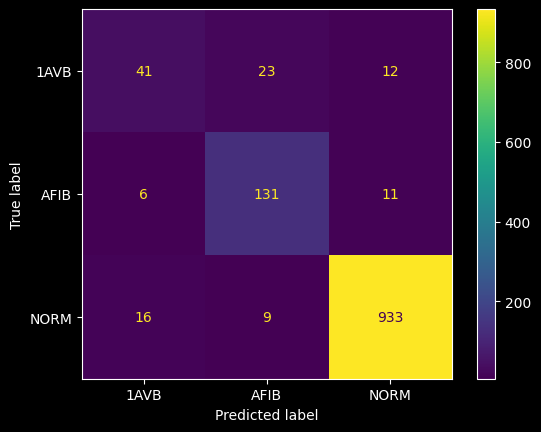

In [35]:
# Evaluate optimized model
model.evaluate(X_test, y_test)

# Convert labels to integers
y_train_int = np.argmax(y_train, axis=1)
y_test_int = np.argmax(y_test, axis=1)

# Convert prediction labels to integers
predictions = model.predict(X_test)
predictions_int = np.argmax(predictions, axis=1)

# Print classification report
print(classification_report(y_test_int, predictions_int, target_names= ['1AVB', 'AFIB', 'NORM']))

# Visualize confusion matrix
matrix = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test_int, predictions_int), display_labels=['1AVB', 'AFIB', 'NORM']).plot()